In [1]:
%cd ../..

/home/eli/AnacondaProjects/epych


In [2]:
%env DASK_LOGGING__DISTRIBUTED=CRITICAL
%env SPYTMPDIR=/mnt/data/tmp_storage
%env SPYLOGLEVEL=CRITICAL
%env SPYPARLOGLEVEL=CRITICAL

env: DASK_LOGGING__DISTRIBUTED=CRITICAL
env: SPYTMPDIR=/mnt/data/tmp_storage
env: SPYLOGLEVEL=CRITICAL
env: SPYPARLOGLEVEL=CRITICAL


In [3]:
import collections
import functools
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import quantities as pq

import epych
from epych.statistics import alignment, spectrum

[striatum:3644975] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.striatum.1000/jf.0/2691563520/shared_mem_cuda_pool.striatum could be created.
[striatum:3644975] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


In [4]:
%matplotlib inline

In [5]:
logging.basicConfig(level=logging.INFO)

In [6]:
ADAPTED_ONSET = pq.Quantity(-1.0) * pq.second
ADAPTED_OFFSET = pq.Quantity(-0.5) * pq.second
ODDBALL_ONSET = pq.Quantity(-1.9017372477960602e-14) * pq.second
ODDBALL_OFFSET = pq.Quantity(0.5004545430388676) * pq.second
OFFSET = pq.Quantity(0.010) * pq.second
EVENTS = {
    "Oddball": (ODDBALL_ONSET.magnitude, 'lightgreen'),
    "Offset": (ODDBALL_OFFSET.magnitude, 'red'),
}
FREQ_RANGE = (spectrum.THETA_BAND[0].magnitude, spectrum.GAMMA_BAND[1].magnitude)
FORCE_RECOMPUTE = False

In [7]:
CONDITIONS = ["lonaive", "go_gloexp", "go_seqctl", "lo_gloexp", "lo_rndctl", "igo_seqctl"]
LAMINAE = {
    'L2/3': lambda loc: "2/3" in loc,
    'L4': lambda loc: "4" in loc,
    'L5/6': lambda loc: "5" in loc or "6" in loc,
    'L1/6': lambda loc: "1" in loc or "6" in loc,
}

In [8]:
BANDS = {
    "Theta": spectrum.THETA_BAND,
    "Alpha/Beta": spectrum.ALPHA_BETA_BAND,
    "Gamma": spectrum.LOW_GAMMA_BAND,
}
BAND_NAMES = {
    "Theta": "theta",
    "Alpha/Beta": "alphabeta",
    "Gamma": "gamma"
}

In [9]:
area_titles = {
    "VISal": "AL",
    "VISam": "AM",
    "VISl": "LM",
    "VISp": "V1",
    "VISpm": "PM",
    "VISrl": "RL",
}
def stattitle(name, stat, layer=None):
    suffix = " (%s)" % layer if layer else ""
    if name in area_titles:
        return area_titles[name] + suffix
    return name + suffix
anatomical_areas = ['VISp', 'VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']

In [10]:
def initialize_spectrum(key, signal, path=None):
    area = os.path.commonprefix([loc for loc in signal.channels.location])
    return epych.statistics.spectrum.Spectrogram(signal.df, signal.channels, signal.f0, taper="hann", path=path + "/" + key, time_window=0.200)

In [11]:
def baselined_oscillatory(spectrogram):
    return spectrogram.oscillatory().baseline(-0.250 * pq.second, -0.050 * pq.second, decibels=True)

def oscillatory_oddball(spectrogram):
    return spectrogram[(ODDBALL_ONSET - OFFSET).magnitude:(ODDBALL_OFFSET + OFFSET).magnitude].oscillatory()

In [12]:
full_tfrs = {}
spectrograms = {}

In [13]:
for cond in CONDITIONS:
    cond_path = "/mnt/data/000253/grand_spectrogram_downsample4_%s" % cond
    raw_spectrograms = epych.statistic.Summary.unpickle(cond_path, epych.statistics.spectrum.Spectrogram).results()
    spectrograms[cond] = raw_spectrograms.smap(oscillatory_oddball)
    full_tfrs[cond] = raw_spectrograms.smap(baselined_oscillatory)
    del raw_spectrograms
    logging.info("Loaded LFP spectrograms across condition %s" % cond)

INFO:root:Loaded LFP spectrograms across condition lonaive
INFO:root:Loaded LFP spectrograms across condition go_gloexp
INFO:root:Loaded LFP spectrograms across condition go_seqctl
INFO:root:Loaded LFP spectrograms across condition lo_gloexp
INFO:root:Loaded LFP spectrograms across condition lo_rndctl
INFO:root:Loaded LFP spectrograms across condition igo_seqctl


In [14]:
PVALUE = 1e-2

In [15]:
CONTRASTS = [("go_contrast", "go_gloexp", "go_seqctl"), ("ssa", "lo_gloexp", "igo_seqctl"), ("dd", "lo_rndctl", "lonaive")]

In [25]:
CONTRAST_TITLES = {
    "go_contrast": "Global Oddball",
    "ssa": "Stimulus Specific Adaptation",
    "dd": "Deviance Detection"
}
def contrast_stattitle(contrast, name, stat, layer=None):
    suffix = " (%s, %s)" % (CONTRAST_TITLES[contrast], layer) if layer else " (%s)" % CONTRAST_TITLES[contrast]
    return stattitle(name, stat) + suffix

In [17]:
def initialize_grand_cluster_test(key, signals):
    return epych.statistics.grand.GrandNonparametricClusterTest(signals[0].num_channels, len(signals[0].times), alpha=PVALUE, partitions=1000)

In [18]:
contrasts = {}
diffs = {}

In [19]:
def area_name(probe, signals):
    return probe

In [20]:
for (name, condl, condr) in CONTRASTS:
    contrast = epych.statistic.Summary(area_name, initialize_grand_cluster_test)
    contrast._trials = spectrograms[condl]._trials
    contrast_signals = {}
    for k in anatomical_areas:
        contrast_signals[k] = (spectrograms[condl].signals[k].decibels(), spectrograms[condr].signals[k].decibels())
    contrast.calculate([contrast_signals])

    if os.path.exists("/mnt/data/000253/oscillatory_contrasts_" + name + '_01') and not FORCE_RECOMPUTE:
        diffs[name] = epych.recording.EvokedSampling.unpickle("/mnt/data/000253/oscillatory_diffs_" + name + '_01')
        contrasts[name] = epych.recording.EvokedSampling.unpickle("/mnt/data/000253/oscillatory_contrasts_" + name + '_01')
    else:
        area_contrasts = contrast.results()
        diffs[name] = epych.recording.EvokedSampling(epych.recording.empty_intervals(), epych.recording.empty_trials(), epych.recording.default_units(), **{
            k: v['signal'] for k, v in area_contrasts.items()
        })
        diffs[name].pickle("/mnt/data/000253/oscillatory_diffs_" + name + '_01')
    
        contrasts[name] = diffs[name].smap(lambda k, sig: sig.fmap(lambda data: data * area_contrasts[k]['mask']), keys=True)
        contrasts[name].pickle("/mnt/data/000253/oscillatory_contrasts_" + name + '_01')

    logging.info("Nonparametrically contrasted spectrograms for %s" % name)

INFO:root:Nonparametrically contrasted spectrograms for go_contrast
INFO:root:Nonparametrically contrasted spectrograms for ssa
INFO:root:Nonparametrically contrasted spectrograms for dd


In [21]:
CONTRAST_VMAXES = {
    "dd": {
        "Theta": 2.,
        "Alpha/Beta": 2.,
        "Gamma": 2.
    },
    "go_contrast": {
        "Theta": 1.,
        "Alpha/Beta": 1.,
        "Gamma": 0.5
    },
    "ssa": {
        "Theta": 3.,
        "Alpha/Beta": 3.,
        "Gamma": 3.
    },
}

In [22]:
def superficial(tfr_summary, l1=False):
    selector = lambda loc: "2/3" in loc
    if l1:
        selector = lambda loc: selector(loc) or "1" in loc
    return tfr_summary.smap(lambda tfr: tfr.select_channels([selector(loc) for loc in tfr.channels.location]))

def deep(tfr_summary):
    return tfr_summary.smap(lambda tfr: tfr.select_channels(["5" in loc or "6" in loc for loc in tfr.channels.location]))

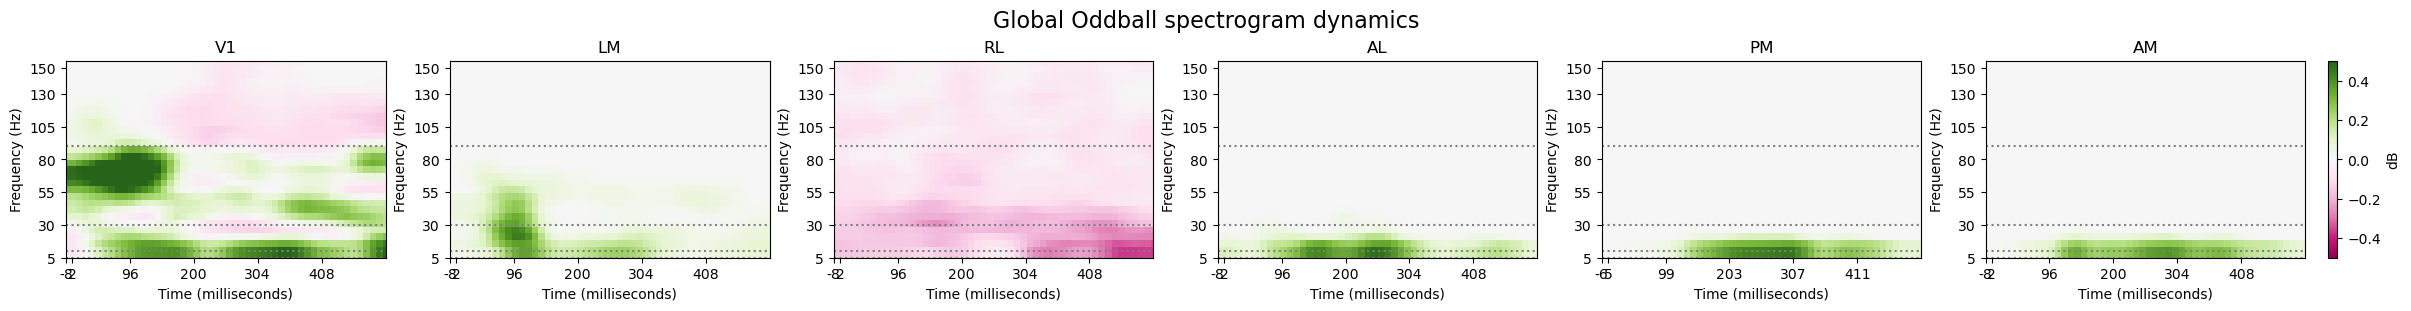

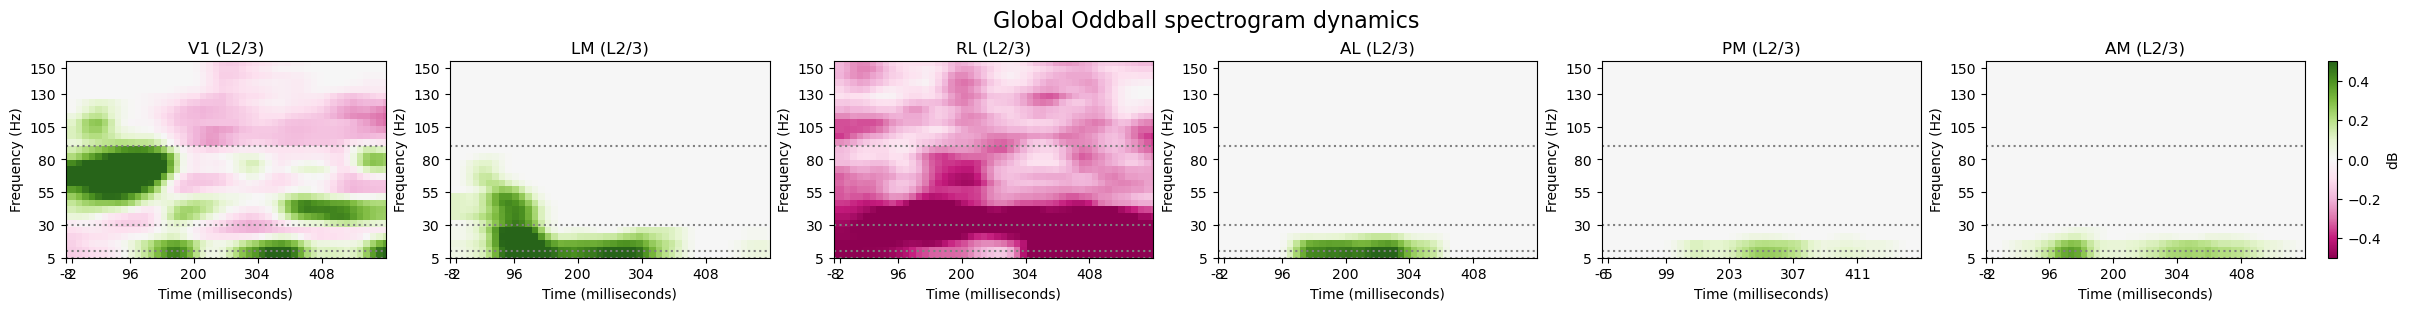

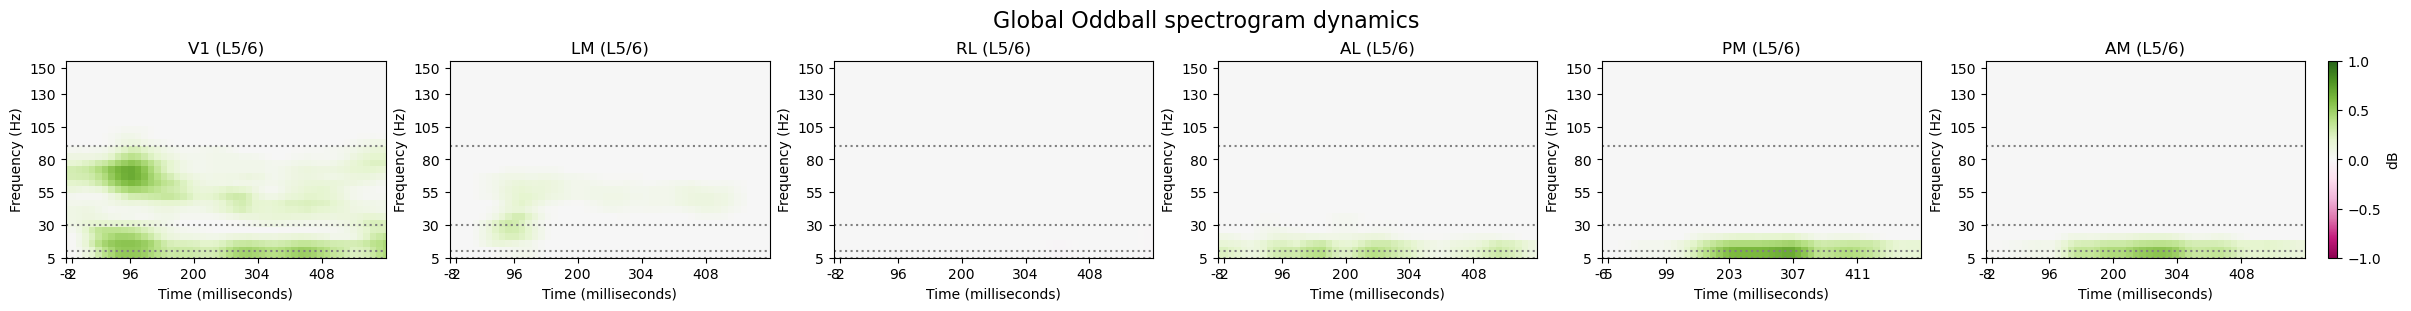

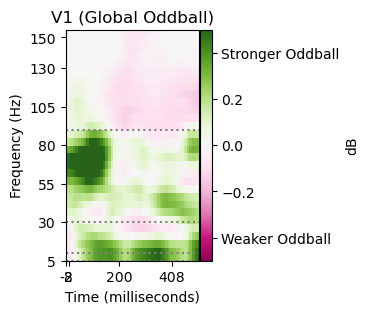

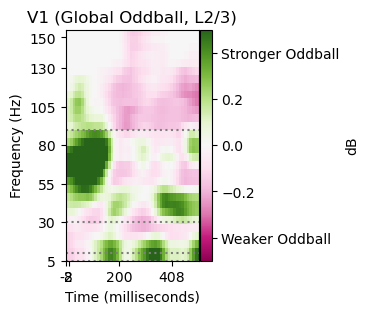

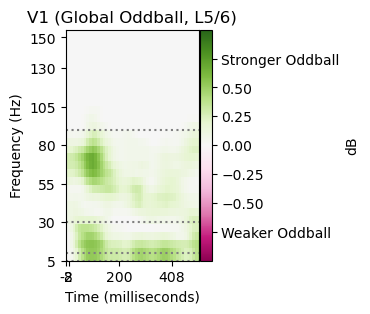

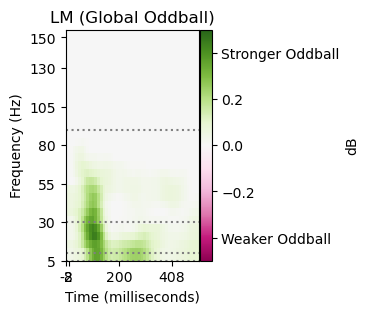

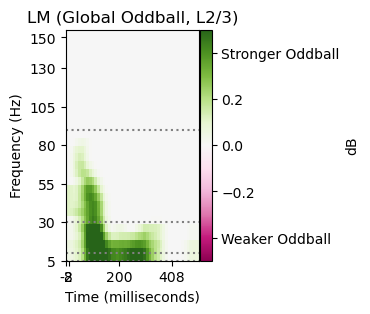

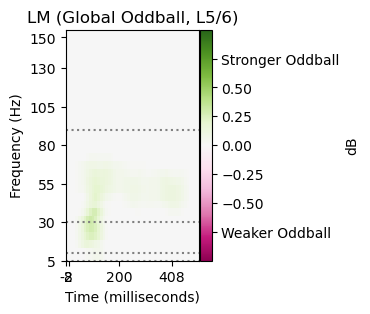

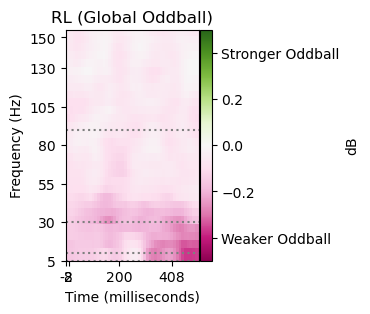

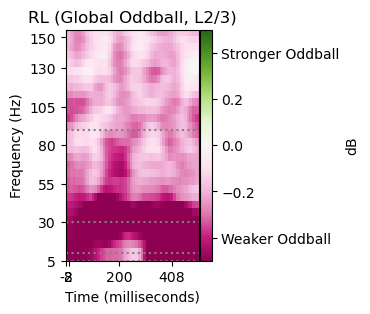

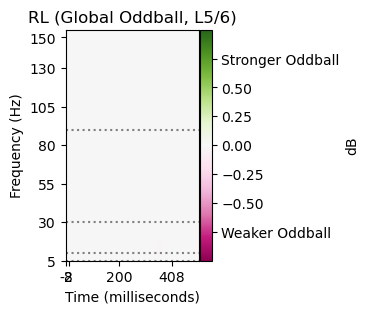

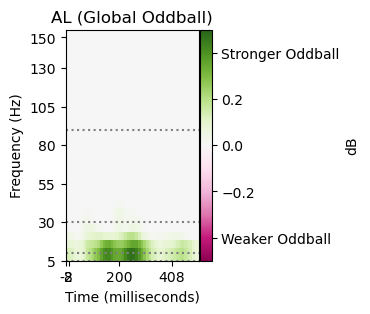

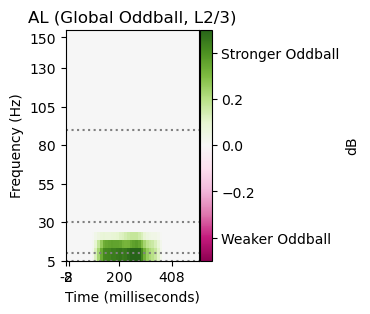

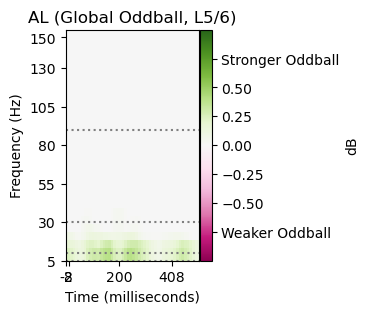

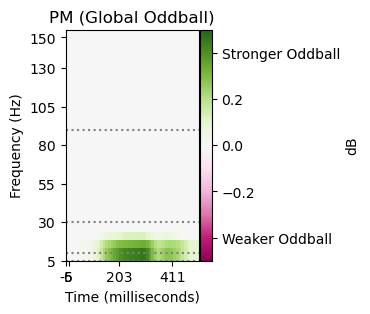

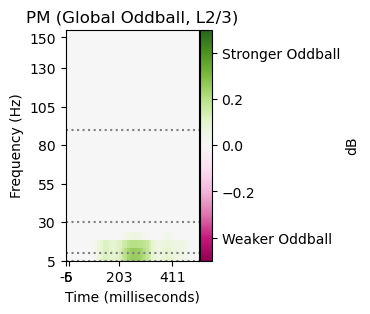

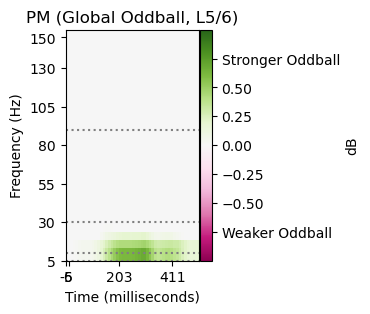

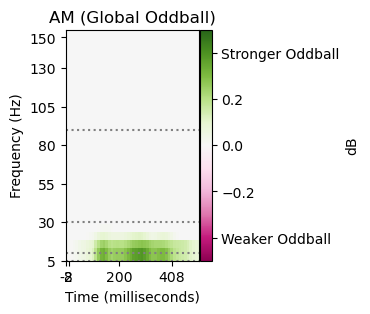

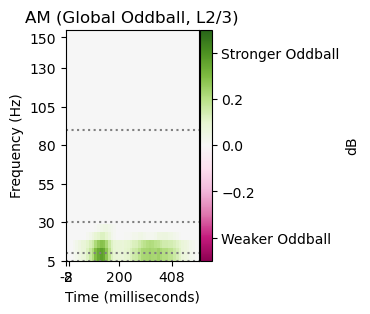

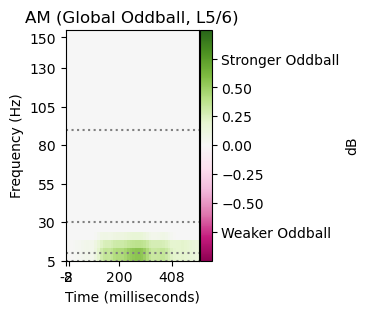

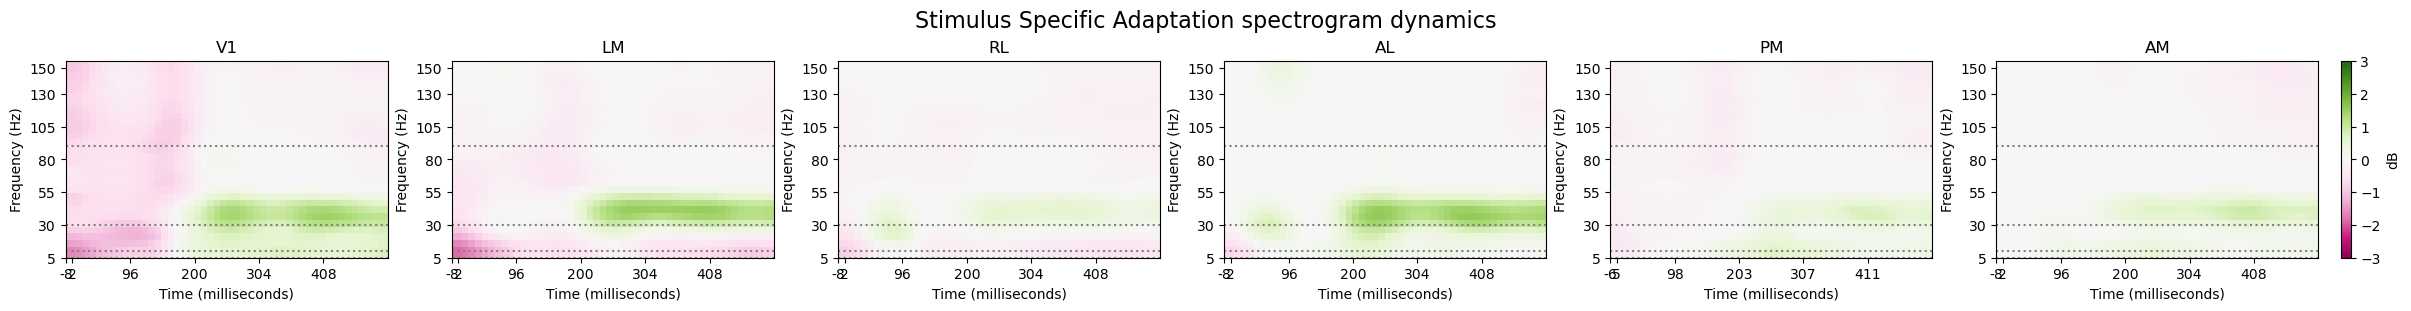

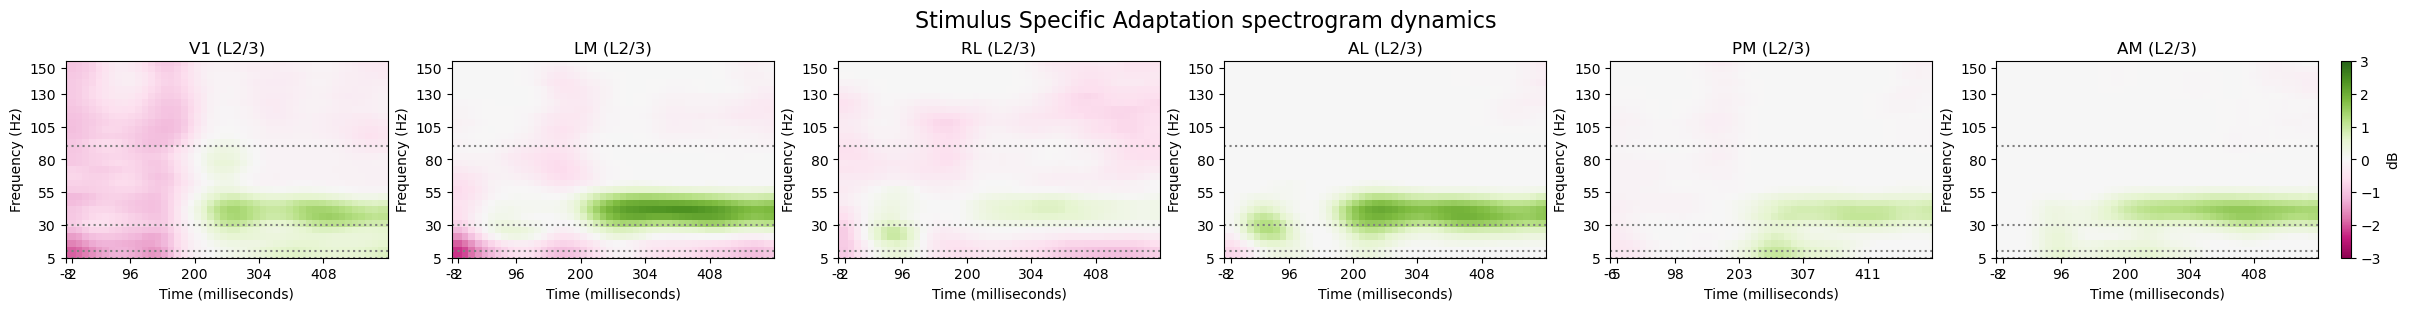

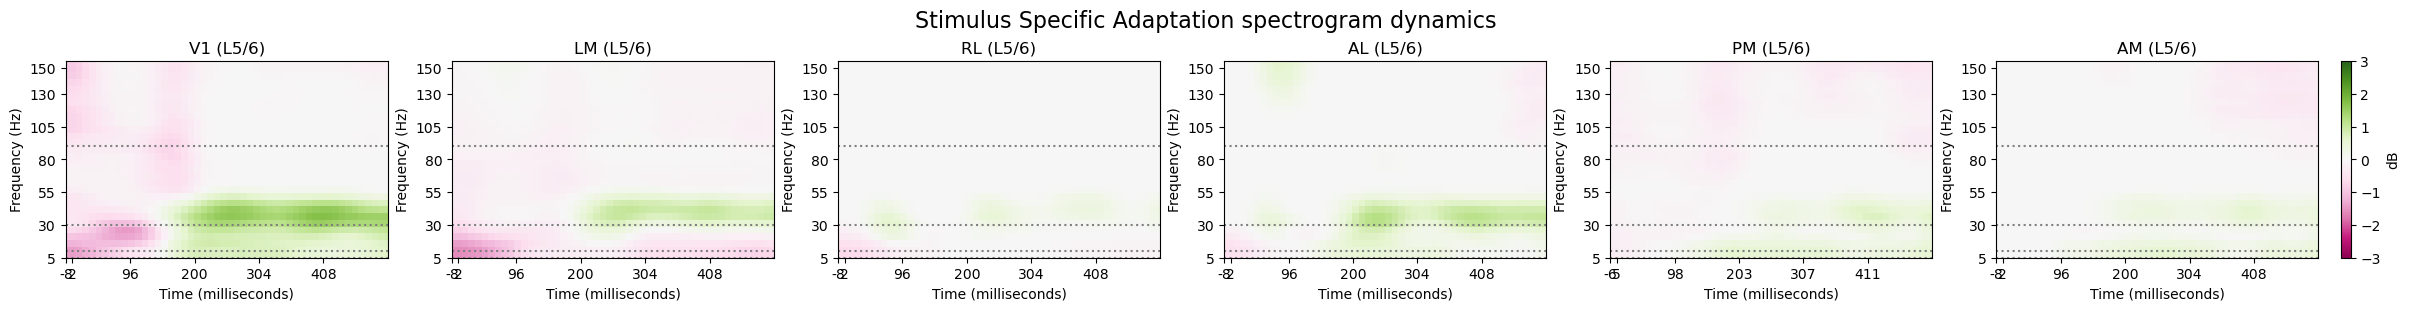

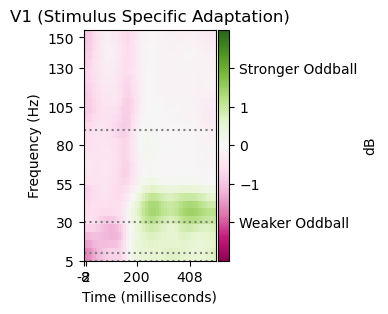

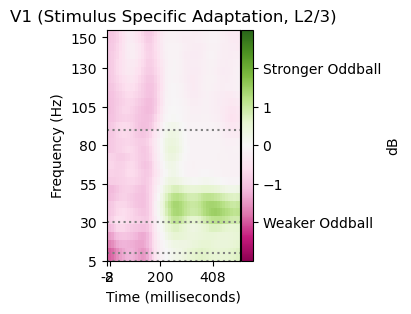

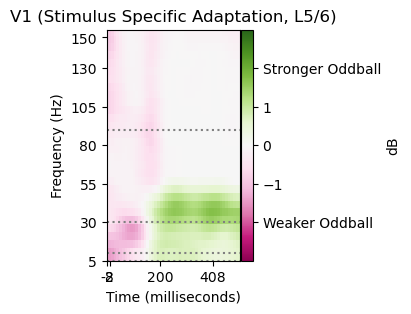

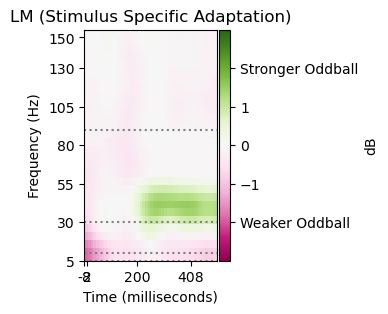

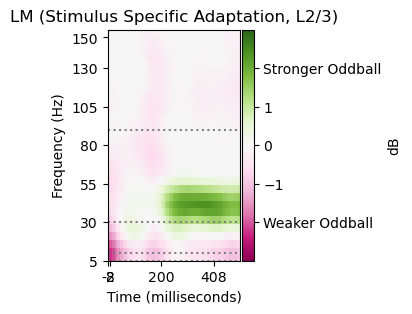

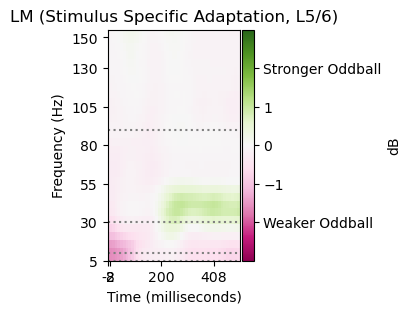

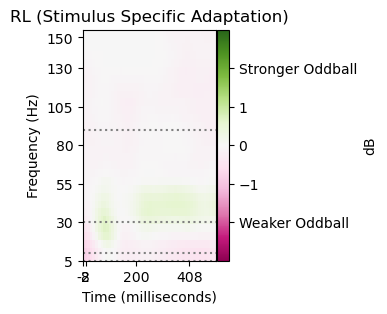

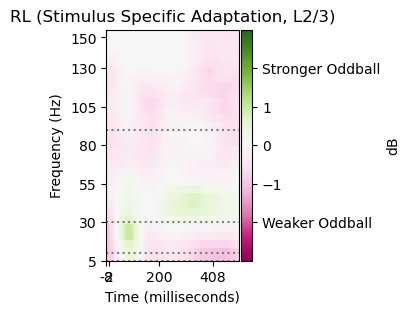

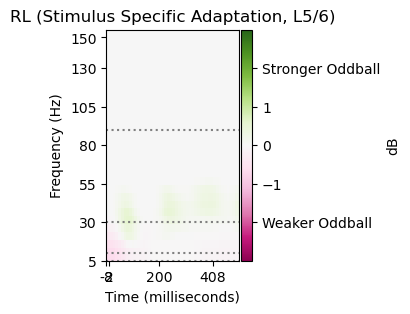

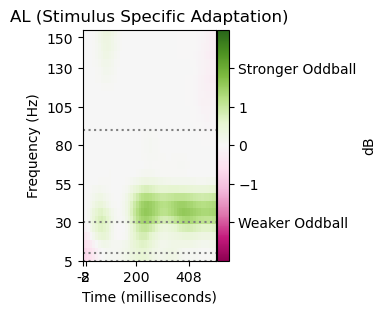

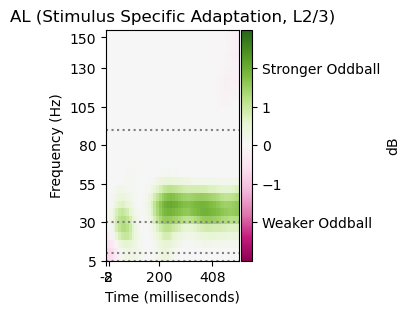

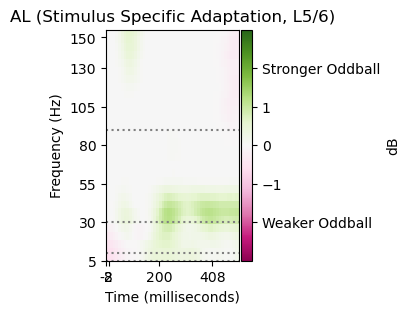

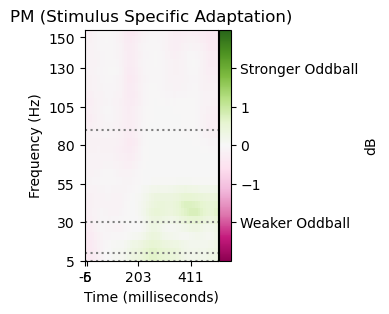

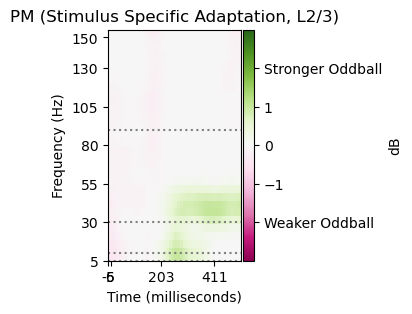

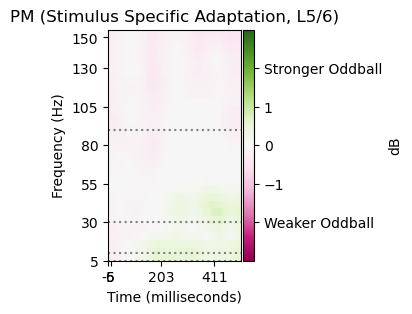

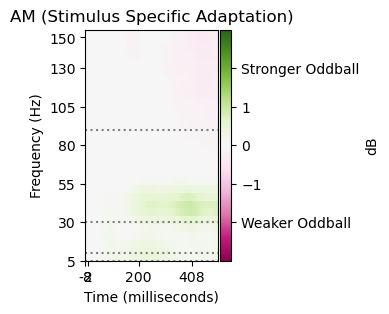

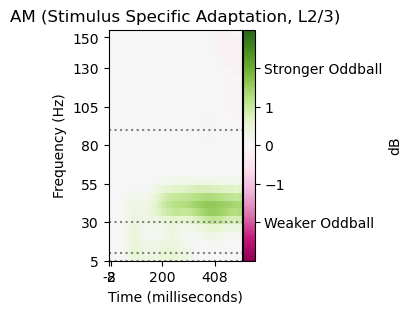

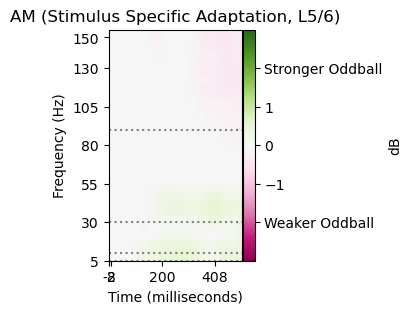

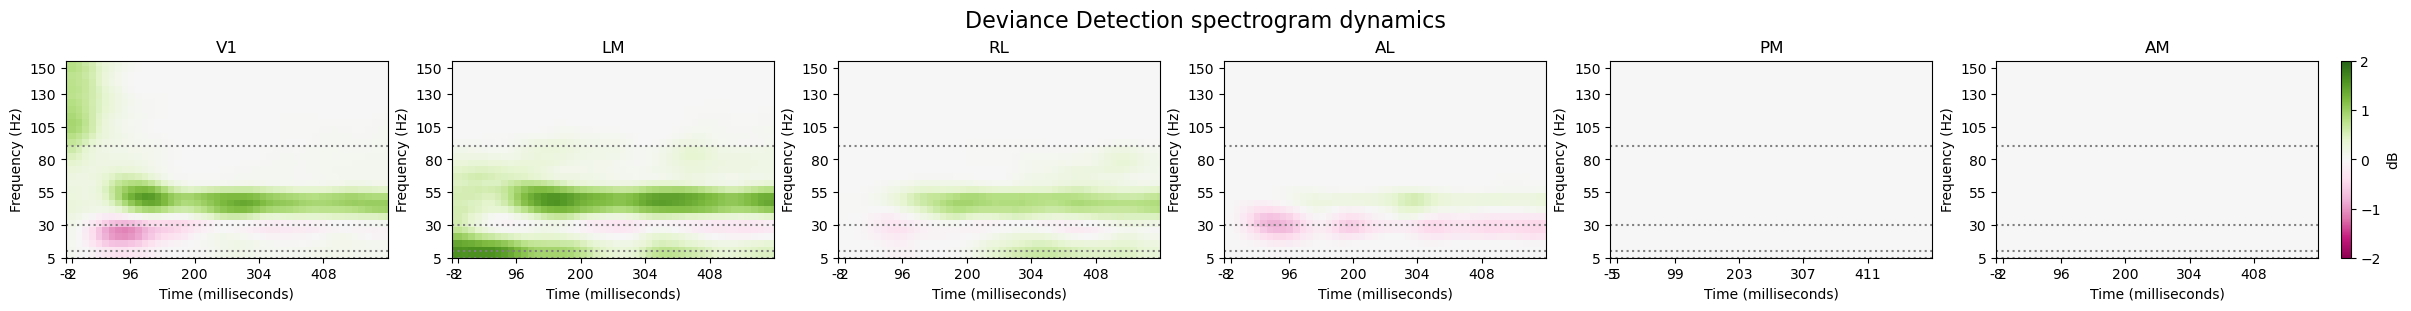

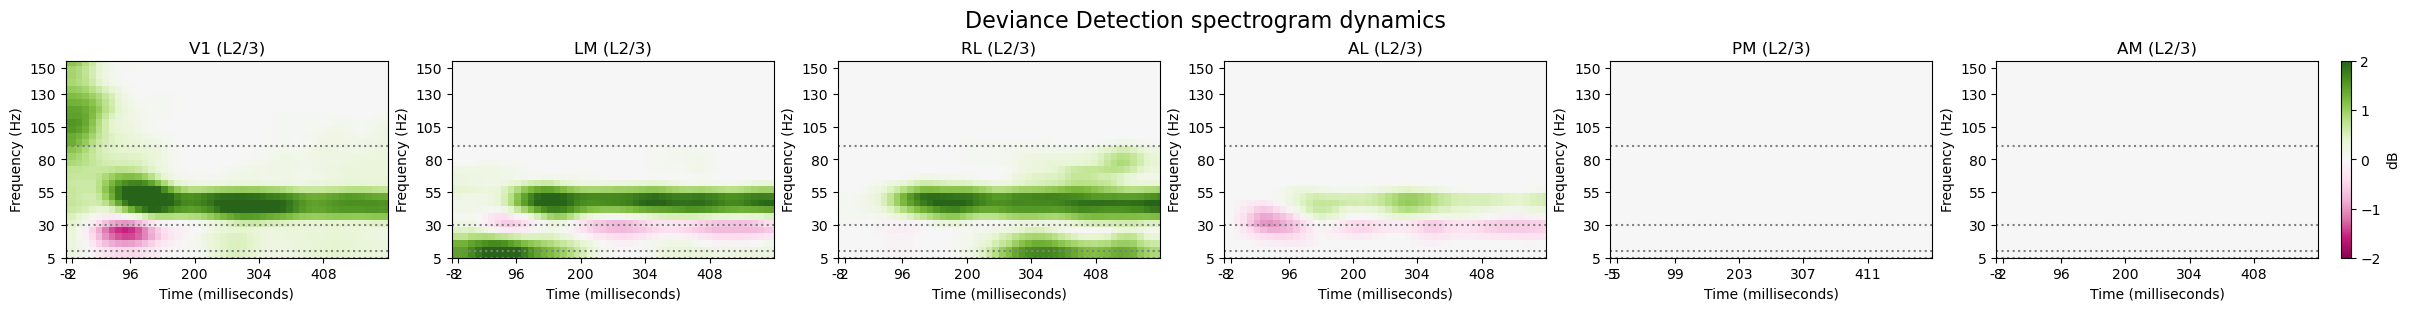

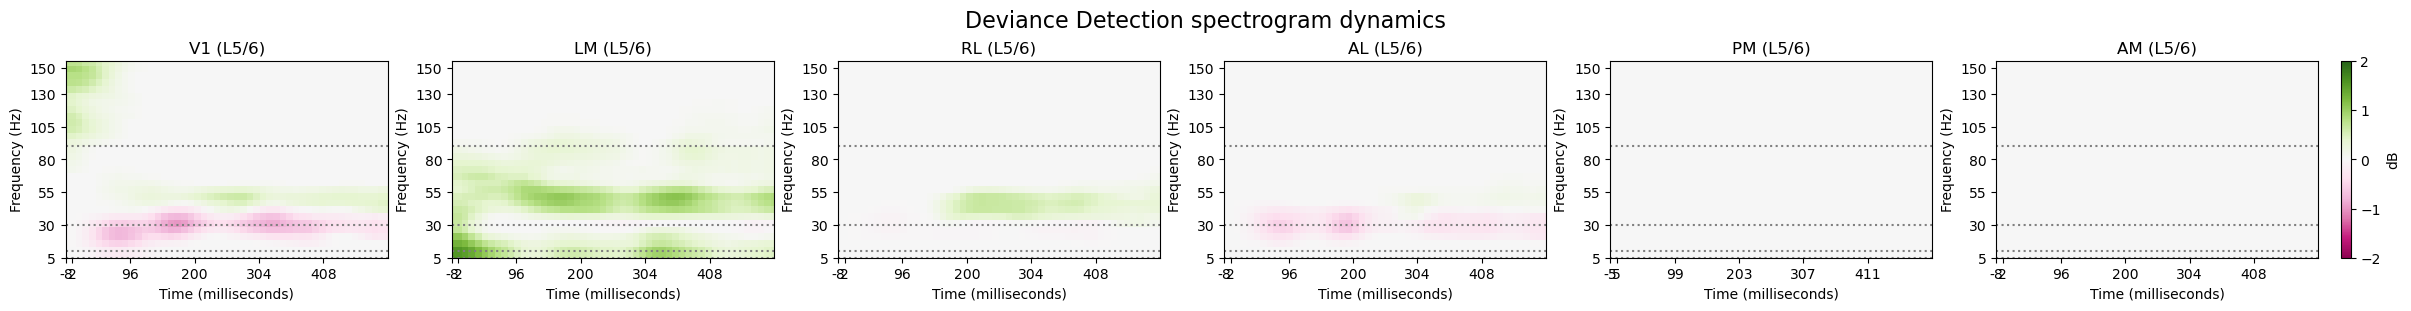

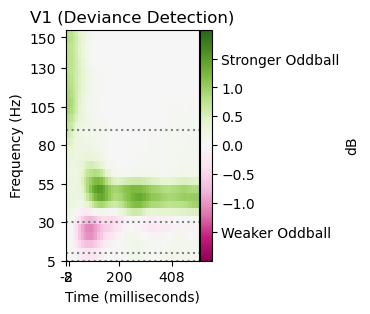

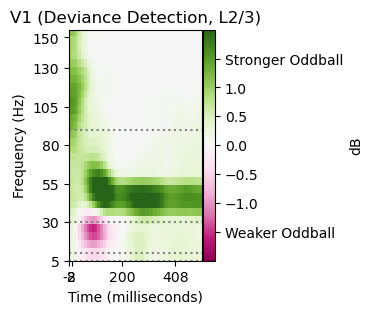

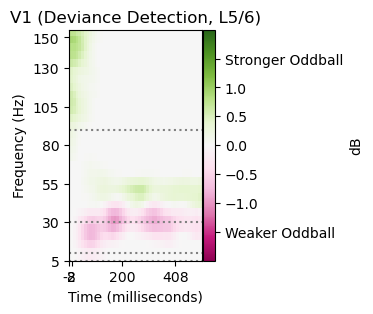

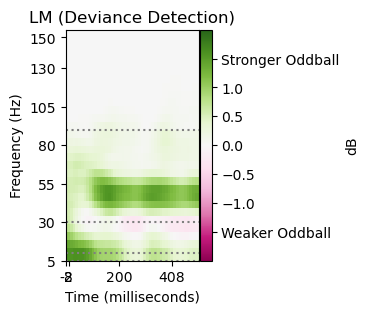

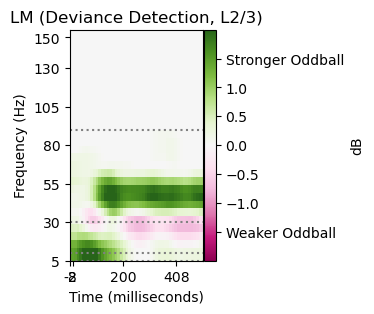

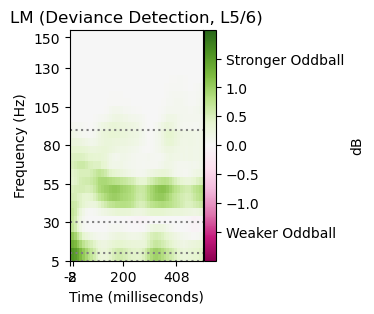

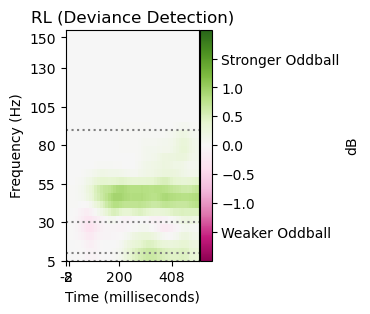

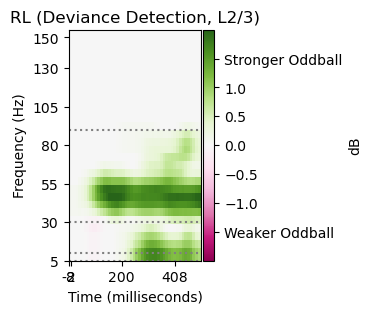

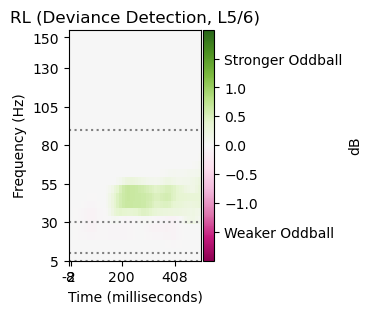

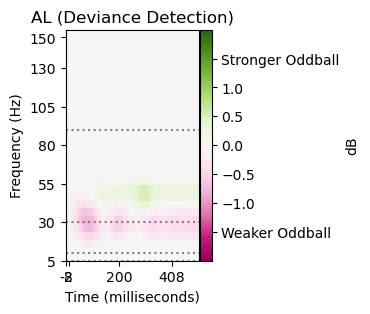

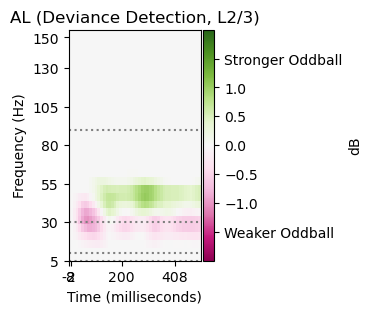

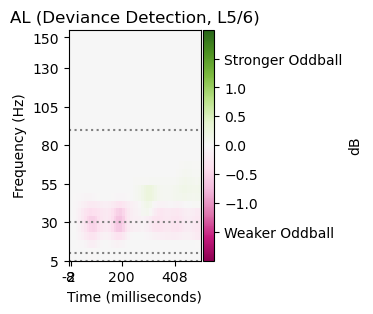

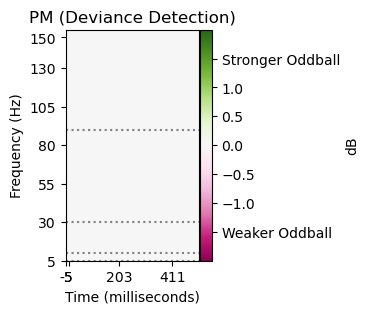

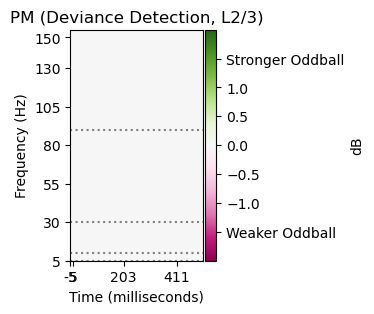

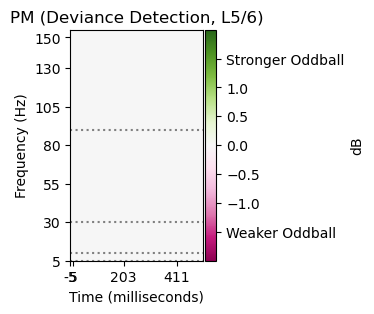

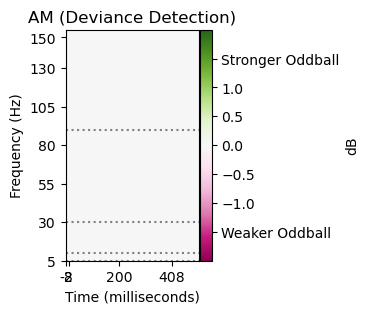

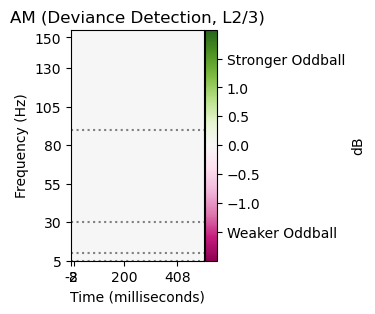

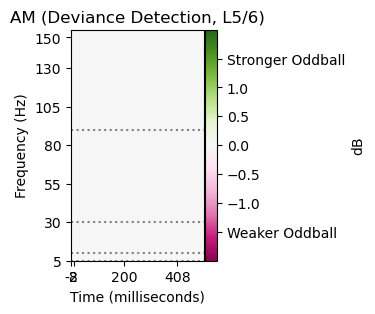

In [26]:
for (name, _, _) in CONTRASTS:
    contrast_title = functools.partial(contrast_stattitle, name)
    contrast = contrasts[name].erp()
    contrast.plot(signals=anatomical_areas, sigtitle=functools.partial(stattitle, layer=None), cmap='PiYG', vmax=CONTRAST_VMAXES[name]["Gamma"], vmin=-CONTRAST_VMAXES[name]["Gamma"],
                  title=CONTRAST_TITLES[name] + " spectrogram dynamics", figure="oscillatory_contrasts_%s_01.png" % name)
    
    superficial_contrast = superficial(contrast)
    superficial_contrast.plot(signals=anatomical_areas, sigtitle=functools.partial(stattitle, layer='L2/3'), cmap='PiYG',
                              vmax=CONTRAST_VMAXES[name]["Gamma"], vmin=-CONTRAST_VMAXES[name]["Gamma"],
                              title=CONTRAST_TITLES[name] + " spectrogram dynamics", figure="oscillatory_contrasts_%s_L23_01.png" % name)

    deep_contrast = deep(contrast)
    deep_contrast.plot(signals=anatomical_areas, sigtitle=functools.partial(stattitle, layer='L5/6'), cmap='PiYG', vmax=CONTRAST_VMAXES[name]["Alpha/Beta"], vmin=-CONTRAST_VMAXES[name]["Alpha/Beta"],
                       title=CONTRAST_TITLES[name] + " spectrogram dynamics", figure="oscillatory_contrasts_%s_L56_01.png" % name)
    for area in anatomical_areas:
        os.makedirs("oscillatory_contrasts_%s_01/" % name, exist_ok=True)

        contrast.signals[area].plot(title=contrast_title(area, contrasts[name].signals[area], layer=None), cmap='PiYG', vmax=CONTRAST_VMAXES[name]["Gamma"], vmin=-CONTRAST_VMAXES[name]["Gamma"],
                                    filename="oscillatory_contrasts_%s_01/%s_oddball.png" % (name, area), cbar_ends=("Stronger Oddball", "Weaker Oddball"))

        superficial_contrast.signals[area].plot(title=contrast_title(area, contrasts[name].signals[area], layer="L2/3"), cmap='PiYG', vmax=CONTRAST_VMAXES[name]["Gamma"], vmin=-CONTRAST_VMAXES[name]["Gamma"],
                                                filename="oscillatory_contrasts_%s_01/%s_L23_oddball.png" % (name, area), cbar_ends=("Stronger Oddball", "Weaker Oddball"))

        deep_contrast.signals[area].plot(title=contrast_title(area, contrasts[name].signals[area], layer="L5/6"), cmap='PiYG', vmax=CONTRAST_VMAXES[name]["Alpha/Beta"], vmin=-CONTRAST_VMAXES[name]["Alpha/Beta"],
                                         filename="oscillatory_contrasts_%s_01/%s_L56_oddball.png" % (name, area), cbar_ends=("Stronger Oddball", "Weaker Oddball"))

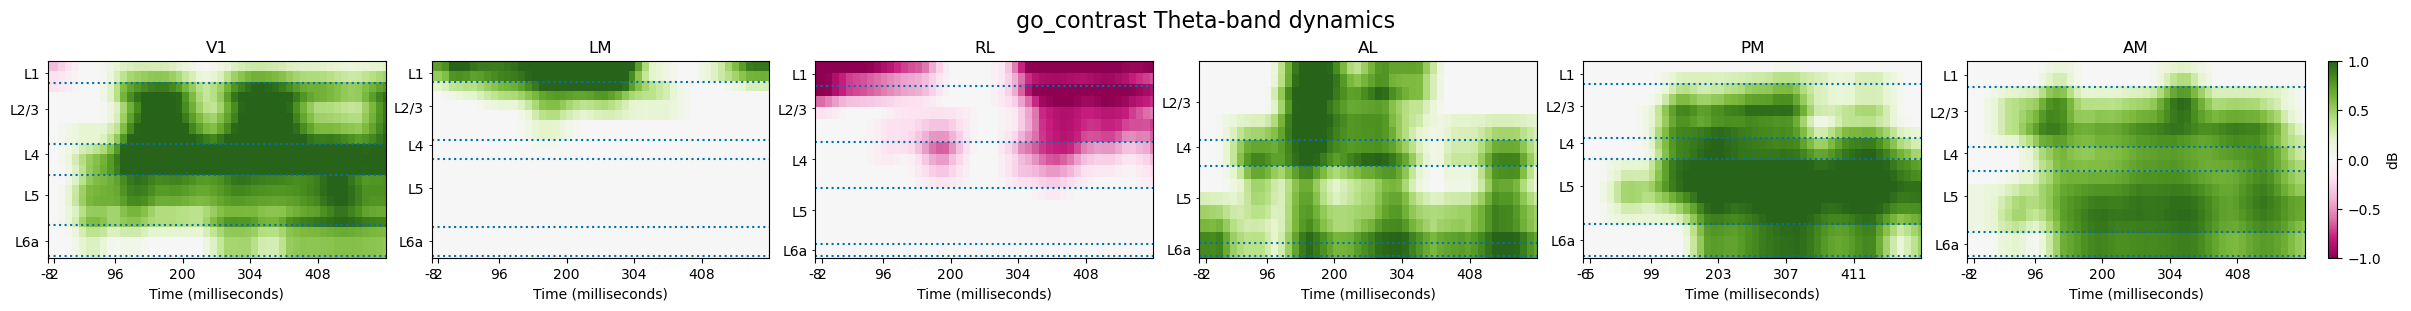

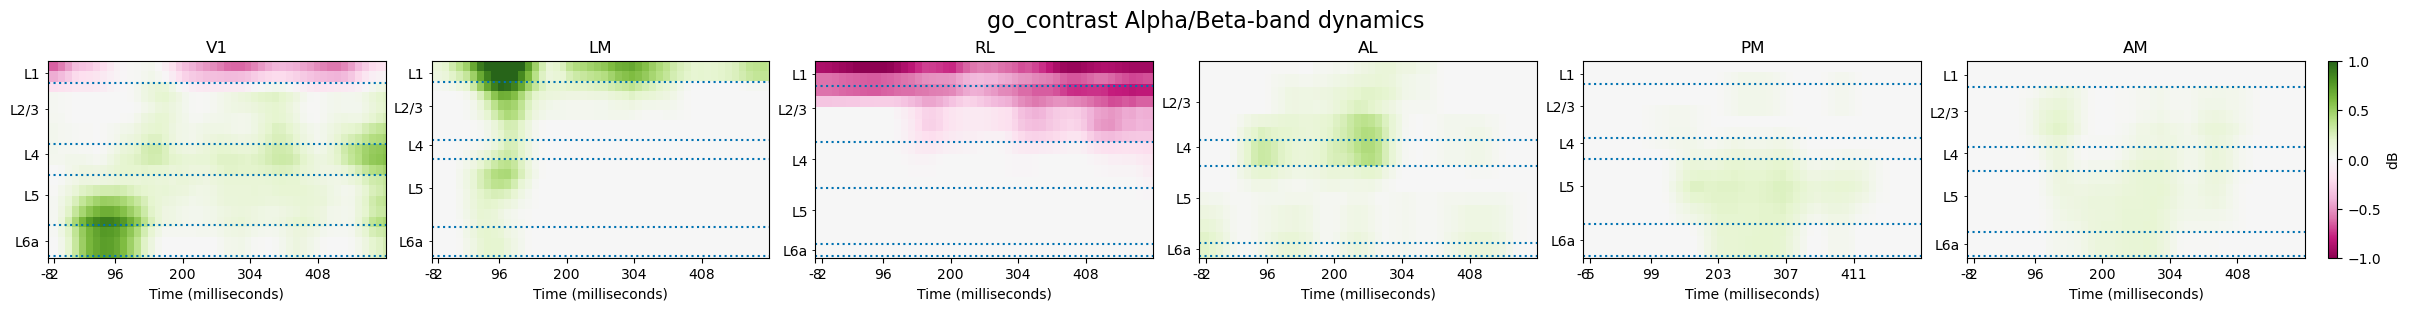

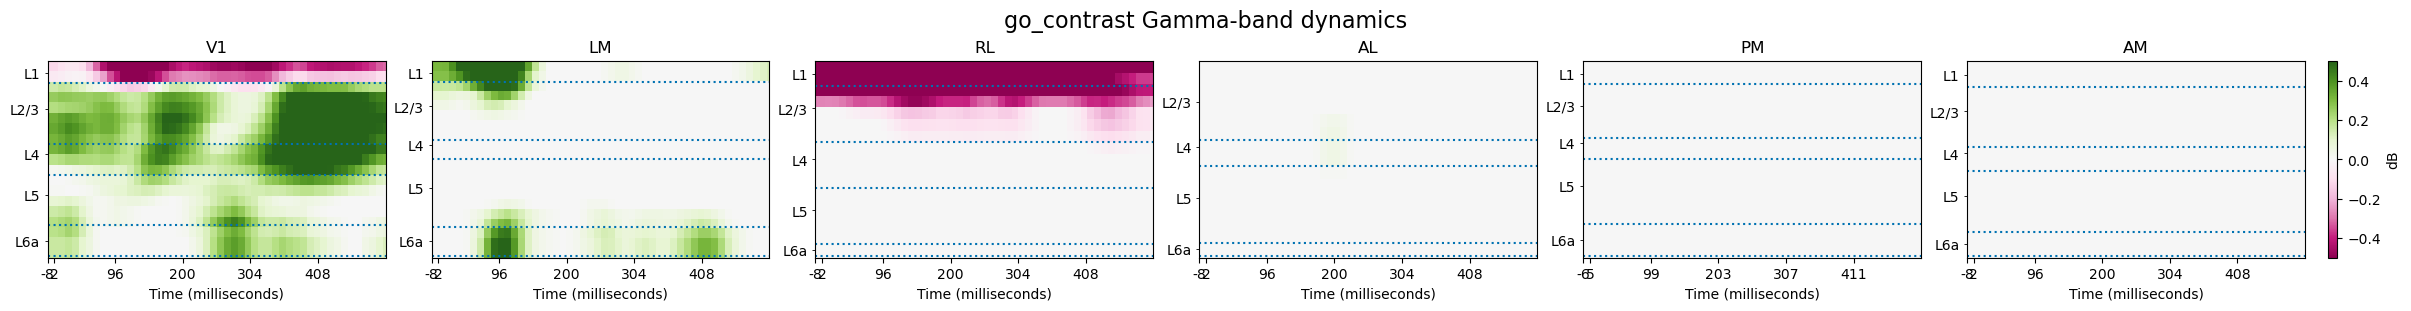

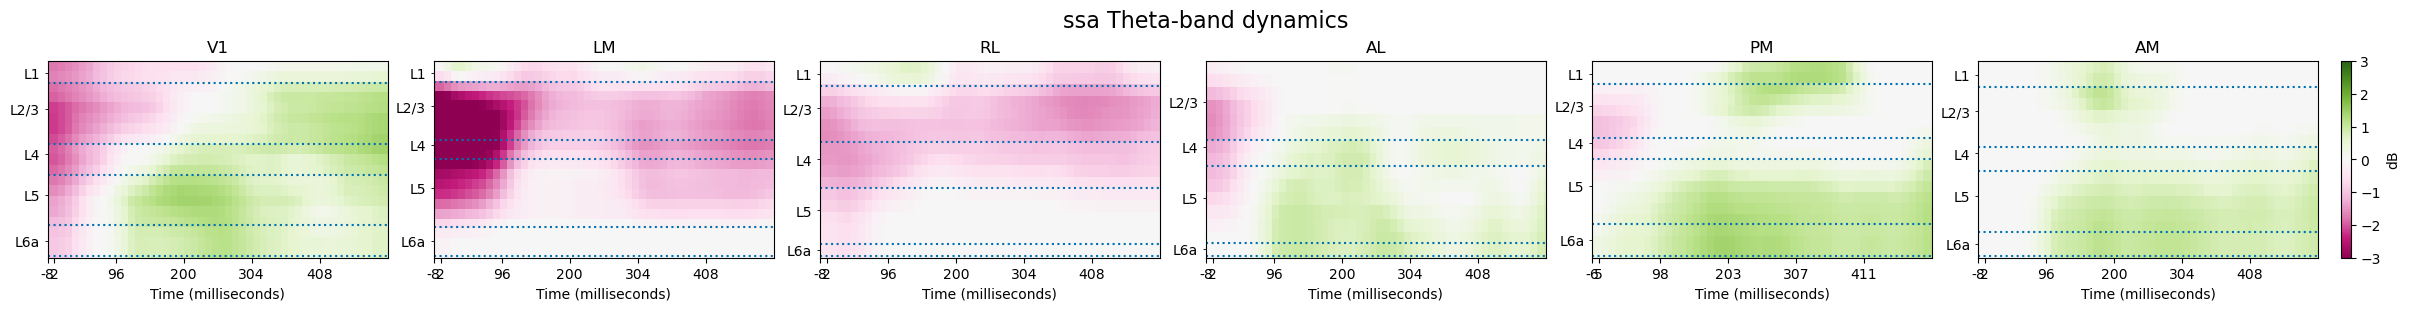

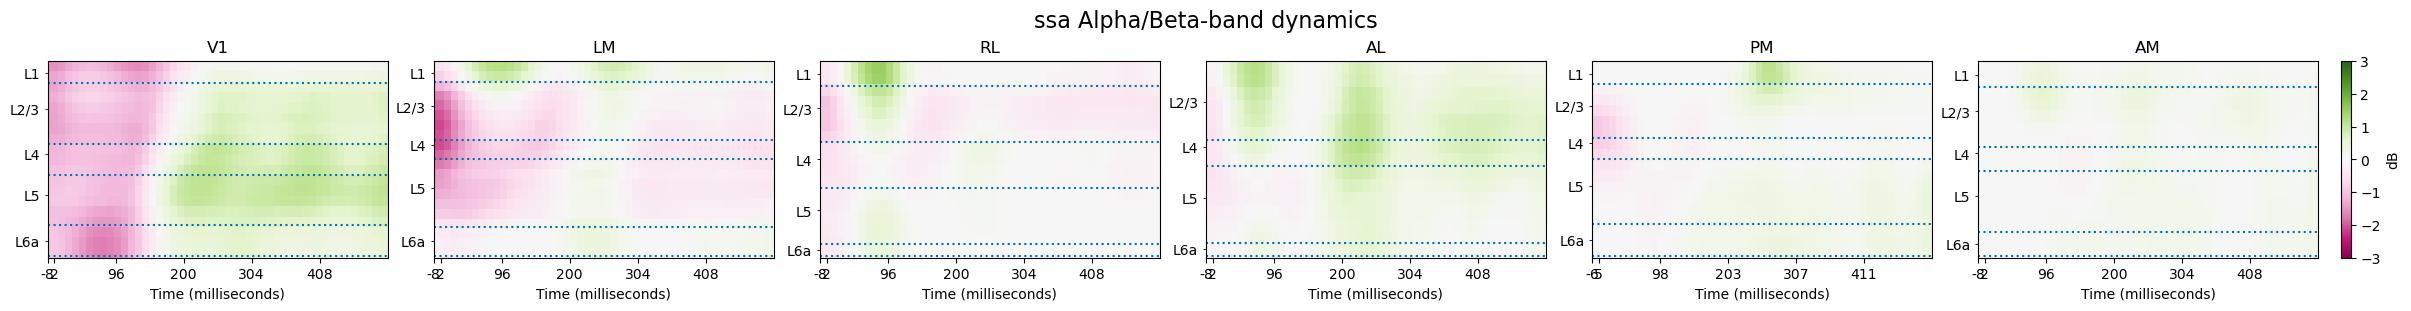

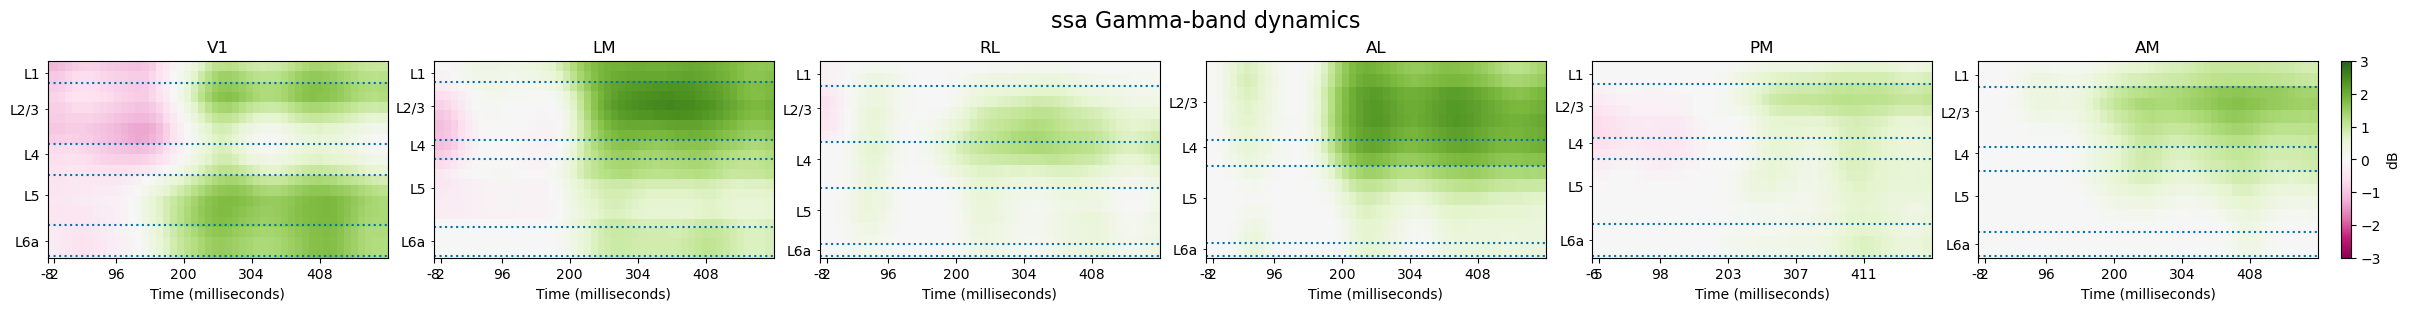

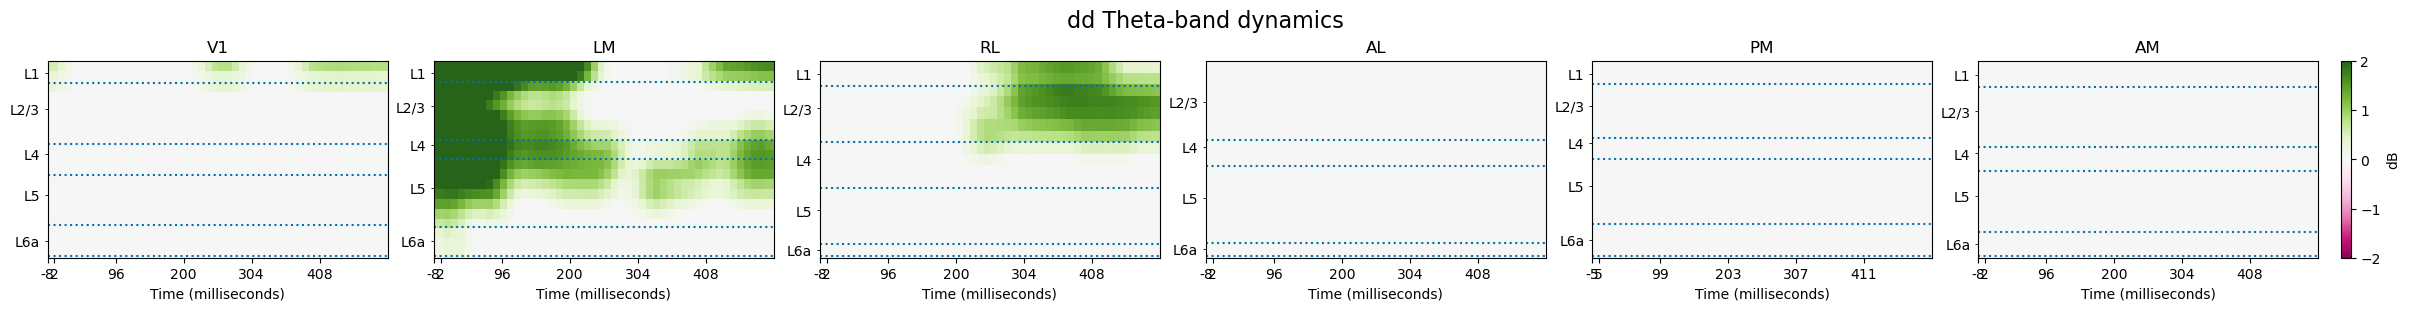

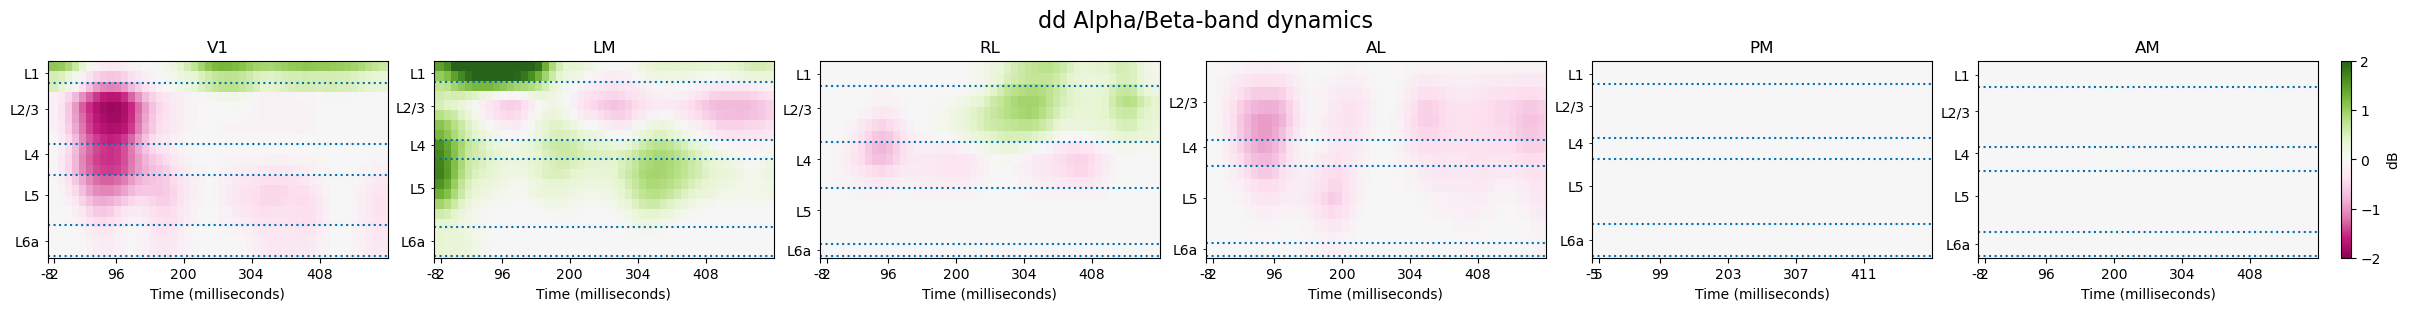

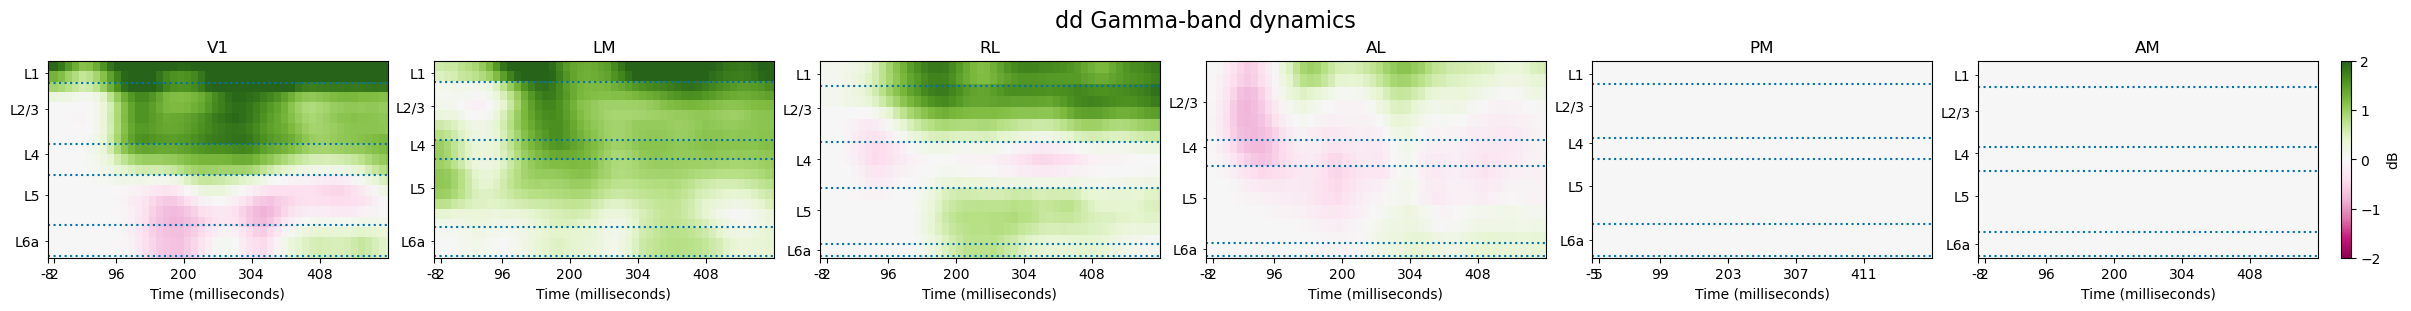

In [27]:
for (name, _, _) in CONTRASTS:
    contrast_title = functools.partial(contrast_stattitle, name)
    contrast = contrasts[name].erp()

    for band, freqs in BANDS.items():
        band_powers = contrast.smap(lambda tfr: tfr.band_power(freqs[0].magnitude, freqs[1].magnitude))
        band_powers.plot(signals=anatomical_areas, sigtitle=stattitle, vmin=-CONTRAST_VMAXES[name][band], vmax=CONTRAST_VMAXES[name][band],
                         title="%s %s-band dynamics" % (name, band), cmap='PiYG',
                         figure="oscillatory_laminar_%s_%s.png" % (name, BAND_NAMES[band]))